<a href="https://colab.research.google.com/github/Sayandt-web/Deep-Optimal-Transport-A-Practical-Algorithm-for-Photo-realistic-Image-Restoration-/blob/main/Deep_Optimal_Transport_A_Practical_Algorithm_for_Photo_realistic_Image_Restoration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Deep Optimal Transport: A Practical Algorithm for
Photo-realistic Image Restoration
(Theo J. Adrai)

https://proceedings.neurips.cc/paper_files/paper/2023/file/c281c5a17ad2e55e1ac1ca825071f991-Paper-Conference.pdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 19.9 MB/s eta 0:00:00


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 196MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth

=== Quantitative Results ===
   Alpha |  PSNR (dB) |     SSIM |    LPIPS
---------------------------------------------
Compressed |      22.19 |   0.5485 |   0.4035
    -0.5 |      21.51 |   0.4553 |   0.4610
     0.0 |      21.56 |   0.4609 |   0.4401
     0.2 |      21.50 |   0.4615 |   0.4304
     0.5 |      21.30 |   0.4608 |   0.4180
     0.8 |      20.99 |   0.4581 |   0.4077
     1.0 |      20.72 |   0.4550 |   0.4031
     1.2 |      20.41 |   0.4509 |   0.4002
     1.5 |      19.89 |   0.4428 |   0.3990
     2.0 |      18.92 |   0.4250 |   0.4052
   Clean |        inf |      1.0 |      0.0


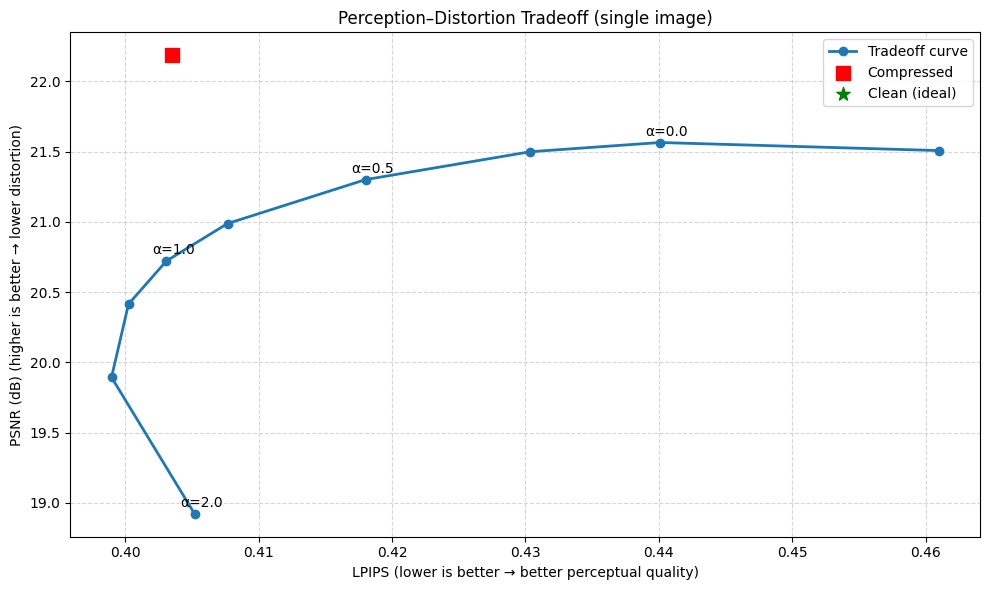

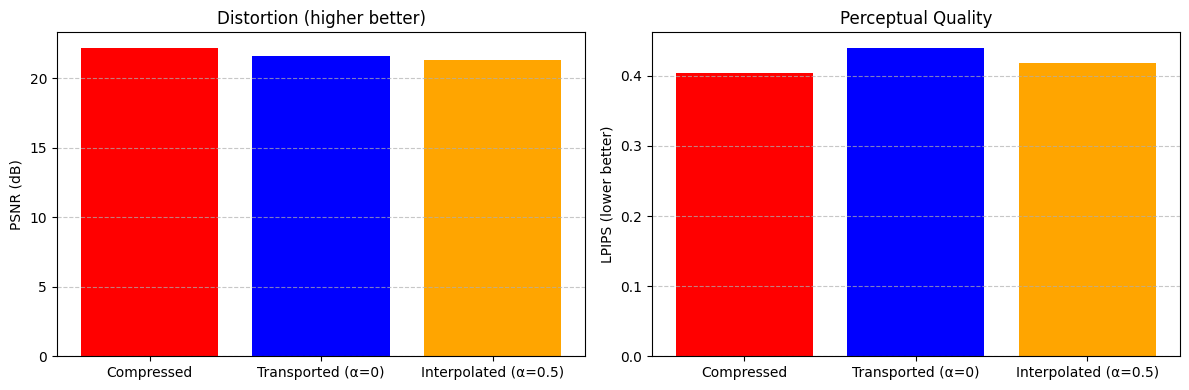

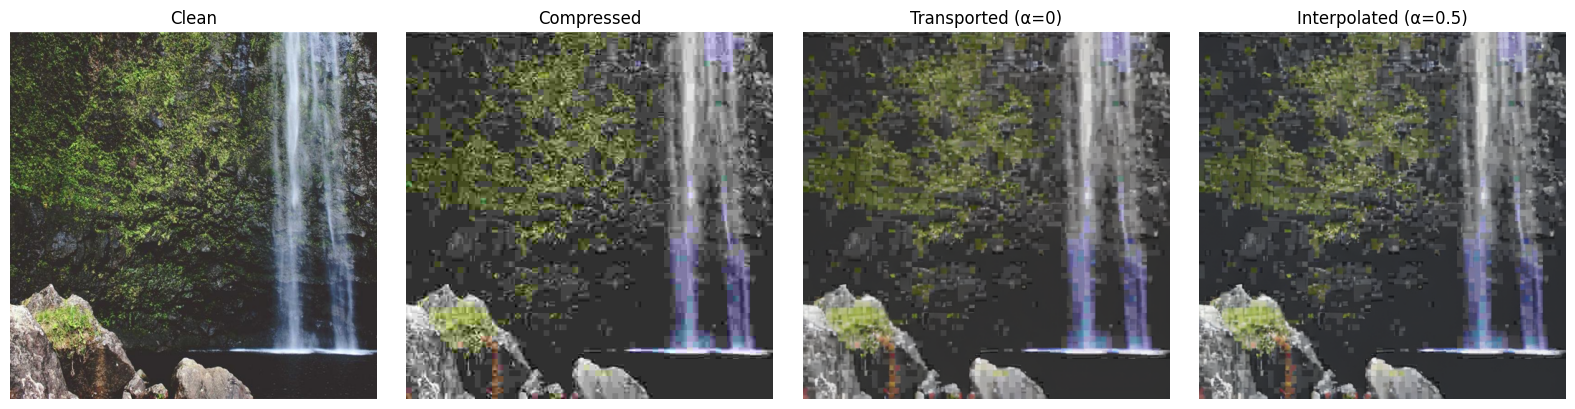


✅ Evaluation complete. The tradeoff curve shows that as we increase α, the image becomes more photorealistic (lower LPIPS) but the PSNR may drop – exactly as the theory predicts.


In [ ]:
# ============================
# 1. Install required packages
# ============================
!pip install diffusers transformers accelerate scipy requests pillow lpips torchmetrics

# ============================
# 2. Imports
# ============================
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode
from diffusers import AutoencoderKL
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

# For metrics
import lpips
from torchmetrics import StructuralSimilarityIndexMeasure as SSIM
from torchmetrics import PeakSignalNoiseRatio as PSNR

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# ============================
# 3. Load pre-trained VAE
# ============================
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
vae.eval()
for param in vae.parameters():
    param.requires_grad = False

# ============================
# 4. Image utilities
# ============================
def pil_to_vae_tensor(pil_img, size=512):
    transform = transforms.Compose([
        transforms.Resize((size, size), interpolation=InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    return transform(pil_img).unsqueeze(0).to(device)

def tensor_to_pil(tensor):
    tensor = tensor.squeeze(0).cpu().clamp(-1, 1)
    tensor = (tensor + 1) / 2
    tensor = tensor.permute(1,2,0).numpy()
    return Image.fromarray((tensor * 255).astype(np.uint8))

def pil_to_tensor(pil_img):
    # For metrics: convert PIL to tensor [0,1]
    transform = transforms.ToTensor()
    return transform(pil_img).unsqueeze(0).to(device)

# ============================
# 5. LatentTransport class (same as before)
# ============================
class LatentTransport:
    def __init__(self, vae, patch_size=3, eps=1e-6):
        self.vae = vae
        self.p = patch_size
        self.eps = eps
        self.mu_src = None
        self.cov_src = None
        self.mu_tgt = None
        self.cov_tgt = None
        self.transport_mat = None
        self.fitted = False

    def _extract_patches(self, latent):
        B, C, H, W = latent.shape
        p = self.p
        patches = F.unfold(latent, kernel_size=p, stride=1, padding=0)
        patches = patches.permute(0,2,1).reshape(-1, C * p * p)
        return patches

    def _fold_patches(self, patches, latent_shape):
        B, C, H, W = latent_shape
        p = self.p
        N = (H - p + 1) * (W - p + 1)
        patches = patches.view(B, N, C * p * p).permute(0,2,1)
        folded = F.fold(patches, output_size=(H, W), kernel_size=p, stride=1, padding=0)
        ones = torch.ones_like(patches)
        count = F.fold(ones, output_size=(H, W), kernel_size=p, stride=1, padding=0)
        folded = folded / (count + 1e-8)
        return folded

    def _compute_stats(self, images):
        latents = []
        for img in images:
            x = pil_to_vae_tensor(img)
            with torch.no_grad():
                z = self.vae.encode(x).latent_dist.sample()
            latents.append(z)
        latent_batch = torch.cat(latents, dim=0)
        patches = self._extract_patches(latent_batch)
        mu = patches.mean(dim=0)
        centered = patches - mu
        cov = (centered.T @ centered) / (patches.size(0) - 1)
        cov += self.eps * torch.eye(cov.size(0), device=cov.device)
        return mu, cov

    def _matrix_sqrt(self, mat):
        eigvals, eigvecs = torch.linalg.eigh(mat)
        eigvals = torch.clamp(eigvals, min=0.0)
        sqrt_eigvals = torch.sqrt(eigvals)
        return eigvecs @ torch.diag(sqrt_eigvals) @ eigvecs.T

    def _matrix_inv_sqrt(self, mat):
        eigvals, eigvecs = torch.linalg.eigh(mat)
        eigvals = torch.clamp(eigvals, min=self.eps)
        inv_sqrt_eigvals = 1.0 / torch.sqrt(eigvals)
        return eigvecs @ torch.diag(inv_sqrt_eigvals) @ eigvecs.T

    def fit(self, natural_images, restored_images):
        self.mu_tgt, self.cov_tgt = self._compute_stats(natural_images)
        self.mu_src, self.cov_src = self._compute_stats(restored_images)

        sqrt_src = self._matrix_sqrt(self.cov_src)
        inv_sqrt_src = self._matrix_inv_sqrt(self.cov_src)
        M = sqrt_src @ self.cov_tgt @ sqrt_src
        sqrt_M = self._matrix_sqrt(M)
        self.transport_mat = inv_sqrt_src @ sqrt_M @ inv_sqrt_src
        self.fitted = True

    def transform(self, image, return_latent=False):
        if not self.fitted:
            raise RuntimeError("Call fit() first.")
        x = pil_to_vae_tensor(image)
        with torch.no_grad():
            z = self.vae.encode(x).latent_dist.sample()
            _, C, H, W = z.shape
            patches = self._extract_patches(z)
            transported_patches = (self.transport_mat @ (patches - self.mu_src).T).T + self.mu_tgt
            latent_shape = (1, C, H, W)
            transported_z = self._fold_patches(transported_patches, latent_shape)
            transported_img = self.vae.decode(transported_z).sample
        if return_latent:
            return transported_img, transported_z
        else:
            return tensor_to_pil(transported_img)

    def interpolate(self, image, alpha):
        if not self.fitted:
            raise RuntimeError("Call fit() first.")
        x = pil_to_vae_tensor(image)
        with torch.no_grad():
            z = self.vae.encode(x).latent_dist.sample()
            patches = self._extract_patches(z)
            transported_patches = (self.transport_mat @ (patches - self.mu_src).T).T + self.mu_tgt
            interpolated_patches = (1 - alpha) * patches + alpha * transported_patches
            _, C, H, W = z.shape
            latent_shape = (1, C, H, W)
            interpolated_z = self._fold_patches(interpolated_patches, latent_shape)
            out = self.vae.decode(interpolated_z).sample
        return tensor_to_pil(out)

# ============================
# 6. Degradation: JPEG compression (heavy)
# ============================
def jpeg_compress(pil_img, quality=5):
    import io
    buffer = io.BytesIO()
    pil_img.save(buffer, format='JPEG', quality=quality, subsampling=0)
    buffer.seek(0)
    return Image.open(buffer)

# ============================
# 7. Download sample images
# ============================
def load_image_from_url(url):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert('RGB')
    return img

# Use four different seeds
urls = [
    "https://picsum.photos/seed/1/800/600",
    "https://picsum.photos/seed/2/800/600",
    "https://picsum.photos/seed/3/800/600",
    "https://picsum.photos/seed/4/800/600"
]

print("Downloading images...")
images = [load_image_from_url(url) for url in urls]
resize = transforms.Resize((512, 512), interpolation=InterpolationMode.BICUBIC)
images = [resize(img) for img in images]

# 2 for fitting, 2 for testing (we'll use the first test image for metrics)
fit_clean = images[:2]
test_clean = images[2:]

# Compress for fit
fit_restored = [jpeg_compress(img, quality=5) for img in fit_clean]

# ============================
# 8. Fit the transport
# ============================
transport = LatentTransport(vae, patch_size=3, eps=1e-6)
transport.fit(fit_clean, fit_restored)

# ============================
# 9. Generate test outputs for various alpha
# ============================
test_img = test_clean[0]
compressed = jpeg_compress(test_img, quality=5)

# Define range of alpha values (including extrapolation)
alphas = [-0.5, 0, 0.2, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
outputs = {}
for alpha in alphas:
    outputs[alpha] = transport.interpolate(compressed, alpha)

# Also get transported (alpha=0) separately
transported = outputs[0]
# Interpolated at 0.5
interpolated = outputs[0.5]

# ============================
# 10. Compute metrics
# ============================
# Prepare clean tensor for reference (normalized to [0,1])
clean_tensor = pil_to_tensor(test_img)
# Prepare metric models
lpips_model = lpips.LPIPS(net='alex').to(device)  # default
ssim = SSIM(data_range=1.0).to(device)
psnr = PSNR(data_range=1.0).to(device)

def compute_metrics(pil_img, clean_tensor):
    # Convert PIL to tensor [0,1]
    pred = pil_to_tensor(pil_img)
    # Compute PSNR
    psnr_val = psnr(pred, clean_tensor).item()
    # Compute SSIM (returns value in [0,1])
    ssim_val = ssim(pred, clean_tensor).item()
    # Compute LPIPS (lower is better)
    lpips_val = lpips_model(pred, clean_tensor).item()
    return psnr_val, ssim_val, lpips_val

# For each alpha, compute metrics
metrics = {}
for alpha, img in outputs.items():
    metrics[alpha] = compute_metrics(img, clean_tensor)

# Also compute for compressed input
compressed_metrics = compute_metrics(compressed, clean_tensor)

# Also for clean (perfect) – just for reference
clean_metrics = (float('inf'), 1.0, 0.0)

# ============================
# 11. Print table
# ============================
print("\n=== Quantitative Results ===")
print(f"{'Alpha':>8} | {'PSNR (dB)':>10} | {'SSIM':>8} | {'LPIPS':>8}")
print("-" * 45)
print(f"{'Compressed':>8} | {compressed_metrics[0]:>10.2f} | {compressed_metrics[1]:>8.4f} | {compressed_metrics[2]:>8.4f}")
for alpha in sorted(alphas):
    psnr_val, ssim_val, lpips_val = metrics[alpha]
    print(f"{alpha:>8.1f} | {psnr_val:>10.2f} | {ssim_val:>8.4f} | {lpips_val:>8.4f}")
print(f"{'Clean':>8} | {'inf':>10} | {1.0:>8.1f} | {0.0:>8.1f}")

# ============================
# 12. Plot tradeoff curve: PSNR vs LPIPS
# ============================
plt.figure(figsize=(10, 6))
# Extract lists
alpha_vals = sorted(alphas)
psnr_vals = [metrics[a][0] for a in alpha_vals]
lpips_vals = [metrics[a][2] for a in alpha_vals]

# Plot the curve
plt.plot(lpips_vals, psnr_vals, marker='o', linestyle='-', linewidth=2, label='Tradeoff curve')
# Add labels for selected points
for i, a in enumerate(alpha_vals):
    if a in [0, 0.5, 1.0, 2.0]:
        plt.annotate(f'α={a:.1f}', (lpips_vals[i], psnr_vals[i]),
                     textcoords="offset points", xytext=(5,5), ha='center')

# Add compressed and clean points
plt.scatter(compressed_metrics[2], compressed_metrics[0], color='red', s=100, label='Compressed', marker='s')
plt.scatter(0, float('inf'), color='green', s=100, label='Clean (ideal)', marker='*')
plt.xlabel('LPIPS (lower is better → better perceptual quality)')
plt.ylabel('PSNR (dB) (higher is better → lower distortion)')
plt.title('Perception–Distortion Tradeoff (single image)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ============================
# 13. Bar chart comparison of key outputs
# ============================
labels = ['Compressed', 'Transported (α=0)', 'Interpolated (α=0.5)']
psnr_bars = [compressed_metrics[0], metrics[0][0], metrics[0.5][0]]
lpips_bars = [compressed_metrics[2], metrics[0][2], metrics[0.5][2]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# PSNR bar
ax1.bar(labels, psnr_bars, color=['red', 'blue', 'orange'])
ax1.set_ylabel('PSNR (dB)')
ax1.set_title('Distortion (higher better)')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
# LPIPS bar
ax2.bar(labels, lpips_bars, color=['red', 'blue', 'orange'])
ax2.set_ylabel('LPIPS (lower better)')
ax2.set_title('Perceptual Quality')
ax2.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ============================
# 14. Display the images side by side
# ============================
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Clean', 'Compressed', 'Transported (α=0)', 'Interpolated (α=0.5)']
images_show = [test_img, compressed, transported, interpolated]
for ax, img, title in zip(axes, images_show, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

print("\n✅ Evaluation complete. The tradeoff curve shows that as we increase α, the image becomes more photorealistic (lower LPIPS) but the PSNR may drop – exactly as the theory predicts.")